Data Augmentation To Address Overfitting In Flower Classification CNN

**In this notebook we will build a CNN to classify flower images. We will also see how our model overfits and how overfitting can be addressed using data augmentation. Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc**

Credits: I used tensorflow offical tutorial: https://www.tensorflow.org/tutorials/images/classification as a reference and made bunch of changes to make it simpler

In below image, 4 new training samples are generated from original sample using different transformations

<img src="daisy2.JPG" />

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

#### Load flowers dataset

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [7]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [8]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [9]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

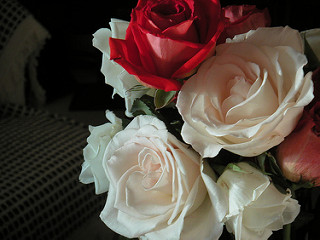

In [10]:
PIL.Image.open(str(roses[1]))

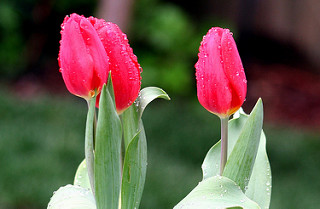

In [11]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [34]:
# check image size
image = cv2.imread(str(tulips[0]))
print(image.shape)  # (height, width, channels)

(209, 320, 3)


In [35]:
image = cv2.imread(str(roses[0]))
print(image.shape)  # (height, width, channels)

(240, 179, 3)


Read flowers images from disk into numpy array using opencv

In [12]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [13]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [14]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [15]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [16]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [17]:
img.shape

(240, 179, 3)

In [18]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [19]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [20]:
X = np.array(X)
y = np.array(y)

#### Train test split

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

#### Preprocessing: scale images

In [22]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

#### Build convolutional neural network and train it

In [23]:
len(flowers_images_dict)

5

In [24]:
num_classes = len(flowers_images_dict)

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)              

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.2803 - loss: 1.5691
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - accuracy: 0.5471 - loss: 1.1169
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.6036 - loss: 0.9711
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.6920 - loss: 0.7869
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.7660 - loss: 0.6332
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8294 - loss: 0.4708
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.8777 - loss: 0.3679
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9402 - loss: 0.1982
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - accuracy: 0.9785 - loss: 0.0786
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9905 - loss: 0.0435
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9843 - loss: 0.0616
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11

In [ ]:
# model evaluation
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=2) #verbose=2 means it will print the progress bar
print(f'\nTest accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

29/29 - 1s - 28ms/step - accuracy: 0.6329 - loss: 1.9841

Test accuracy: 0.6329
Test loss: 1.9841


**Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (63.29%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting**

In [30]:
predictions = model.predict(X_test_scaled)
score = tf.nn.softmax(predictions[0])
score

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([6.0268358e-06, 9.9999392e-01, 4.3521893e-09, 1.6006710e-14,
       3.8971124e-13], dtype=float32)>

In [31]:
np.argmax(score)

np.int64(1)

In [32]:
y_test[0]

np.int64(1)

#### Improve Test Accuracy Using Data Augmentation

In [37]:
img_height, img_width = 180, 180
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
    ]
)

c:\Workspace\MyProjects\DeepLearning\venv\lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Original Image**

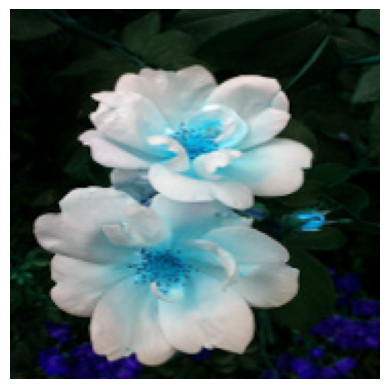

In [38]:
plt.axis('off')
plt.imshow(X[0])

**Newly generated training sample using data augmentation**

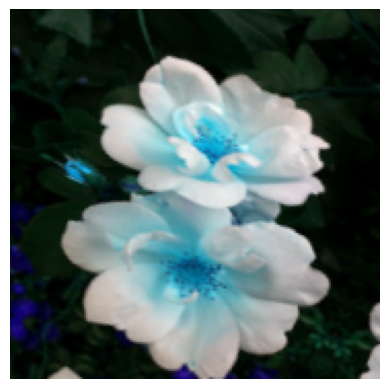

In [39]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

#### Train the model using data augmentation and a drop out layer

In [40]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 203ms/step - accuracy: 0.3459 - loss: 1.4335
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 196ms/step - accuracy: 0.5805 - loss: 1.0537
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.6468 - loss: 0.9317
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.6540 - loss: 0.8810
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.6834 - loss: 0.8107
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.7096 - loss: 0.7517
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.7300 - loss: 0.7053
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.7504 - loss: 0.6423
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.7561 - loss: 0.6339
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.7626 - loss: 0.6276
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.7736 - loss: 0.6018
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15

In [41]:
# model evaluation
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=2)
print(f'\nTest accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

29/29 - 1s - 32ms/step - accuracy: 0.7200 - loss: 1.1075

Test accuracy: 0.7200
Test loss: 1.1075


**You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 72.74%**

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


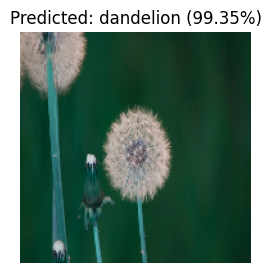

Actual class: 2
Actual class name: dandelion
Predicted class: 2
Predicted class name: dandelion
Predicted class score: 99.35%


In [71]:
test_index = 2
# model predictions
predictions = model.predict(X_test_scaled)
score = tf.nn.softmax(predictions[test_index])

# Display the image and prediction
plt.figure(figsize=(3, 3))
plt.axis('off')
plt.imshow(X_test[test_index].astype("uint8"))
plt.title(f'Predicted: {list(flowers_images_dict.keys())[np.argmax(score)]} ({100 * np.max(score):.2f}%)')
plt.show()

# print actual class and actual class name
print(f'Actual class: {y_test[test_index]}')
print(f'Actual class name: {list(flowers_images_dict.keys())[y_test[test_index]]}')

print('=================================')
print(f'Predicted class: {np.argmax(score)}')
print(f'Predicted class name: {list(flowers_images_dict.keys())[np.argmax(score)]}')
print(f'Predicted class score: {100 * np.max(score):.2f}%')

### Create function for this testing

In [84]:
def check_actual_predicted_class(test_index):
    # model predictions
    predictions = model.predict(X_test_scaled)
    score = tf.nn.softmax(predictions[test_index])

    # Display the image and prediction
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(X_test[test_index].astype("uint8"))
    plt.title(f'Predicted: {list(flowers_images_dict.keys())[np.argmax(score)]} ({100 * np.max(score):.2f}%)')
    plt.show()

    # print actual class and actual class name
    actual_class = y_test[test_index]
    actual_class_name = list(flowers_images_dict.keys())[actual_class]
    print(f'Actual class: {actual_class}')
    print(f'Actual class name: {actual_class_name}')
    print(f'Actual path: {str(flowers_images_dict[actual_class_name][test_index])}')
    
    print('=================================')
    pred_class = np.argmax(score)
    pred_class_name = list(flowers_images_dict.keys())[pred_class]
    print(f'Predicted class: {pred_class}')
    print(f'Predicted class name: {pred_class_name}')
    print(f'Predicted path: {str(flowers_images_dict[pred_class_name][test_index])}')
    print(f'Predicted class score: {100 * np.max(score):.2f}%')


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


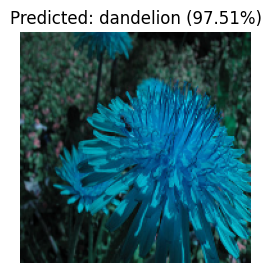

Actual class: 2
Actual class name: dandelion
Actual path: datasets\flower_photos\dandelion\10443973_aeb97513fc_m.jpg
Predicted class: 2
Predicted class name: dandelion
Predicted path: datasets\flower_photos\dandelion\10443973_aeb97513fc_m.jpg
Predicted class score: 97.51%


In [ ]:
check_actual_predicted_class(4)

### Model prediction by image_path

In [ ]:
image_path = str(flowers_images_dict['dandelion'][9])
image_path.split("\\")[-2]

'dandelion'

In [ ]:
# check_actual_predicted_class for the file path
def check_actual_predicted_class_by_path(image_path):
    # Load the image
    img = cv2.imread(image_path)
    resized_img = cv2.resize(img, (180, 180))
    img_scaled = resized_img / 255.0
    img_scaled = np.expand_dims(img_scaled, axis=0)  # Add batch dimension
    
    # model predictions
    predictions = model.predict(img_scaled)
    score = tf.nn.softmax(predictions[0])

    pred_class = np.argmax(score)
    pred_class_name = list(flowers_images_dict.keys())[pred_class] 
    
    # Print actual class and actual class name
    print(f'Image Path: {image_path}')
    actual_class_name = image_path.split("\\")[-2]
    print(f'Actual class name: {actual_class_name}\n') 
     
    print(f'Predicted class: {pred_class}')
    print(f'Predicted class name: {pred_class_name}')
    print(f'Predicted class score: {100 * np.max(score):.2f}%')
    
    # Display the image and prediction
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(resized_img.astype("uint8"))
    plt.title(f'Predicted: {list(flowers_images_dict.keys())[np.argmax(score)]} ({100 * np.max(score):.2f}%)')
    plt.show()
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Image Path: datasets\flower_photos\tulips\13561912705_e5eeb41433_z.jpg
Actual class name: tulips

Predicted class: 4
Predicted class name: tulips
Predicted class score: 47.33%


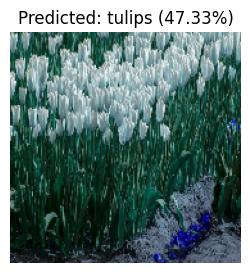

In [128]:
path = str(flowers_images_dict['tulips'][90])
check_actual_predicted_class_by_path(path)